# Part I - Delay Cause Analysis in U.S. Airline On-Time Performance
## by (your name here)

## Introduction

This analysis explores the **Reporting Carrier On-Time Performance** dataset, which contains U.S. domestic flight records from 1987 to 2022 (2 million sampled rows).

**Primary question: What are the primary causes of flight delays, and do they differ by airline or region?**

The DOT tracks five categories of delay:
- **Carrier Delay** — caused by the airline (maintenance, crew issues, baggage loading, etc.)
- **Weather Delay** — significant meteorological conditions
- **NAS Delay** — National Aviation System (airport operations, heavy traffic, air traffic control)
- **Security Delay** — evacuation, re-boarding, inoperative screening equipment
- **Late Aircraft Delay** — a previous flight using the same aircraft arrived late

> Note: Delay cause data is only available from June 2003 onward.

## Preliminary Wrangling

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

%matplotlib inline
sb.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [11]:
airline_data = pd.read_csv("data-visualization/airline_2m.csv", encoding="latin-1", low_memory=False)
print(f"Dataset shape: {airline_data.shape}")
airline_data.head()

Dataset shape: (2000000, 109)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4WheelsOff,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum
0,1998,1,1,2,5,1998-01-02,NW,19386,NW,N297US,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009,2,5,28,4,2009-05-28,FL,20437,FL,N946AT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013,2,6,29,6,2013-06-29,MQ,20398,MQ,N665MQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010,3,8,31,2,2010-08-31,DL,19790,DL,N6705Y,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2006,1,1,15,7,2006-01-15,US,20355,US,N504AU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Select columns relevant to delay cause analysis
cols = ['Year', 'Month', 'DayOfWeek', 'Reporting_Airline',
        'Origin', 'OriginCityName', 'OriginStateName',
        'Dest', 'DestCityName', 'DestStateName',
        'DepDelay', 'ArrDelay', 'ArrDelayMinutes', 'ArrDel15',
        'Cancelled', 'Diverted', 'Distance', 'DistanceGroup',
        'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

df = airline_data[cols].copy()

# Define delay cause columns
delay_causes = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

# Subset: flights with delay cause data (all 5 causes non-null)
delayed = df.dropna(subset=delay_causes).copy()

print(f"Total flights: {len(df):,}")
print(f"Flights with delay cause data: {len(delayed):,}")
print(f"Percentage with cause data: {len(delayed)/len(df)*100:.1f}%")
print(f"\nYear range with cause data: {delayed['Year'].min()} - {delayed['Year'].max()}")

Total flights: 2,000,000
Flights with delay cause data: 221,803
Percentage with cause data: 11.1%

Year range with cause data: 2003 - 2020


In [13]:
delayed[delay_causes].describe().round(1)

,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,221803.0,221803.0,221803.0,221803.0,221803.0
mean,16.9,2.9,15.4,0.1,22.1
std,46.2,21.1,30.5,2.1,41.6
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,4.0,0.0,0.0
75%,17.0,0.0,19.0,0.0,27.0
max,1878.0,1847.0,1343.0,219.0,1407.0


### What is the structure of your dataset?

The dataset contains 2 million sampled flight records with 109 columns covering flight timing, airline information, origin/destination airports, delay metrics, and delay causes. Each row represents a single domestic U.S. flight.

### What is/are the main feature(s) of interest in your dataset?

The five delay cause variables (`CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay`) are the main features of interest. These record the number of delay minutes attributed to each cause for delayed flights.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

- `Reporting_Airline` — to compare delay causes across carriers
- `OriginStateName` — to examine regional patterns
- `Month` and `Year` — to explore seasonal and long-term trends
- `ArrDel15` — binary delay indicator for computing delay rates
- `ArrDelay` — overall delay magnitude

## Univariate Exploration

We start by examining the distributions of individual variables related to flight delays and delay causes.

### Q1: What is the overall distribution of arrival delays?

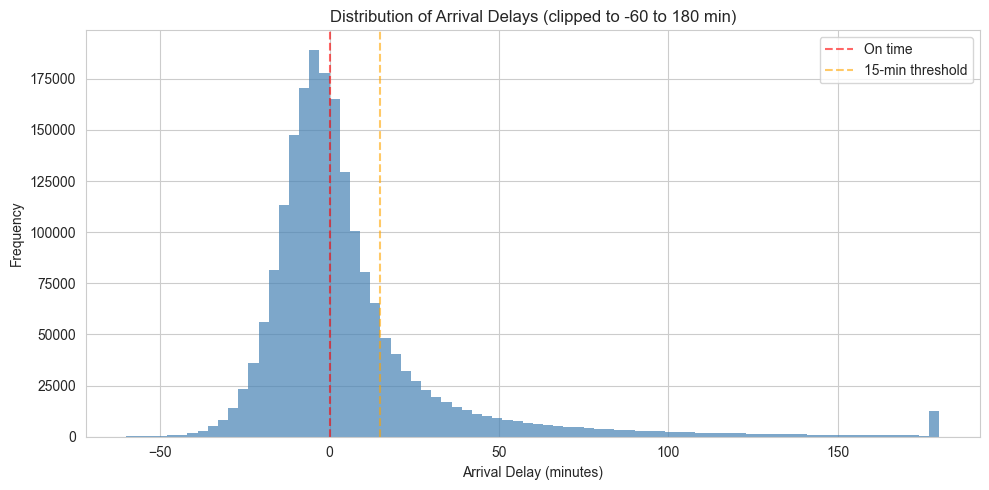

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
clipped = df['ArrDelay'].dropna().clip(-60, 180)
ax.hist(clipped, bins=80, edgecolor='none', alpha=0.7, color='steelblue')
ax.axvline(0, color='red', linestyle='--', alpha=0.6, label='On time')
ax.axvline(15, color='orange', linestyle='--', alpha=0.6, label='15-min threshold')
ax.set_xlabel('Arrival Delay (minutes)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Arrival Delays (clipped to -60 to 180 min)')
ax.legend()
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Q2: How are the individual delay causes distributed?

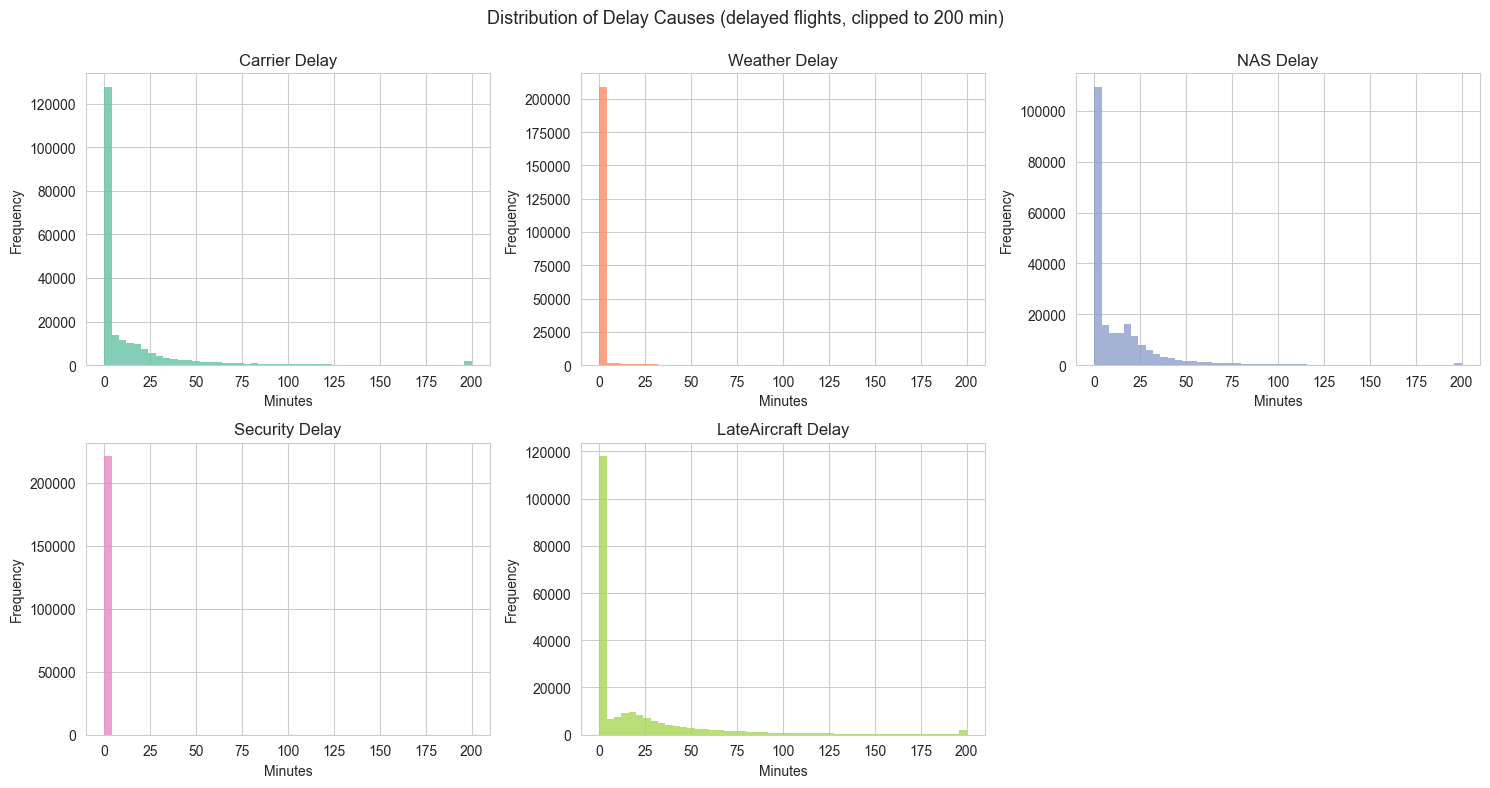

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = sb.color_palette('Set2', 5)
for i, cause in enumerate(delay_causes):
    axes[i].hist(delayed[cause].clip(0, 200), bins=50, edgecolor='none', alpha=0.8, color=colors[i])
    axes[i].set_title(cause.replace('Delay', ' Delay'))
    axes[i].set_xlabel('Minutes')
    axes[i].set_ylabel('Frequency')
axes[5].set_visible(False)
plt.suptitle('Distribution of Delay Causes (delayed flights, clipped to 200 min)', fontsize=13)
plt.tight_layout()
plt.subplots_adjust(top=0.9);

> **Observation:** *(fill in after running)*

### Q3: What proportion of flights are delayed 15+ minutes?

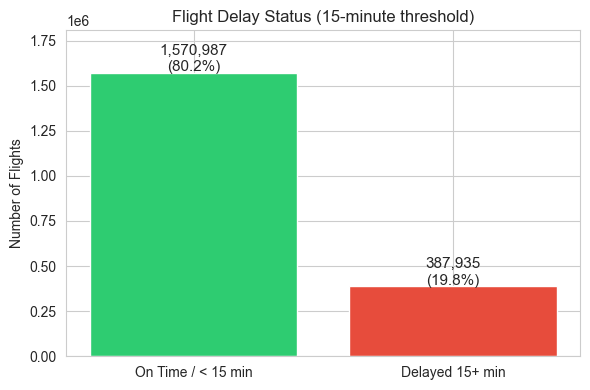

In [16]:
delay_counts = df['ArrDel15'].value_counts().sort_index()
labels = ['On Time / < 15 min', 'Delayed 15+ min']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, delay_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white')
for i, v in enumerate(delay_counts.values):
    ax.text(i, v + len(df)*0.005, f'{v:,}\n({v/delay_counts.sum()*100:.1f}%)', ha='center', fontsize=11)
ax.set_ylabel('Number of Flights')
ax.set_title('Flight Delay Status (15-minute threshold)')
ax.set_ylim(0, delay_counts.max() * 1.15)
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Q4: Which airlines have the most flights in this dataset?

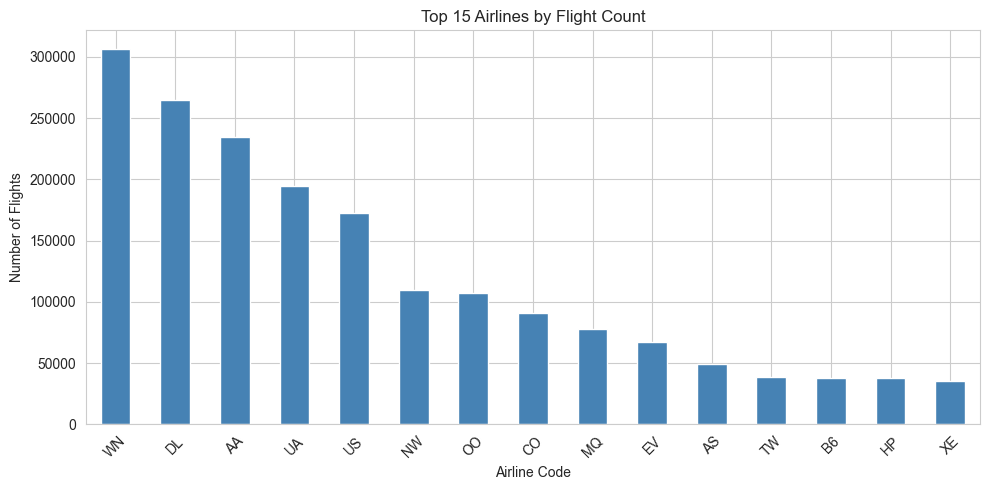

In [17]:
top_airlines = df['Reporting_Airline'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_airlines.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Airline Code')
ax.set_ylabel('Number of Flights')
ax.set_title('Top 15 Airlines by Flight Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Q5: Which states have the most flight departures?

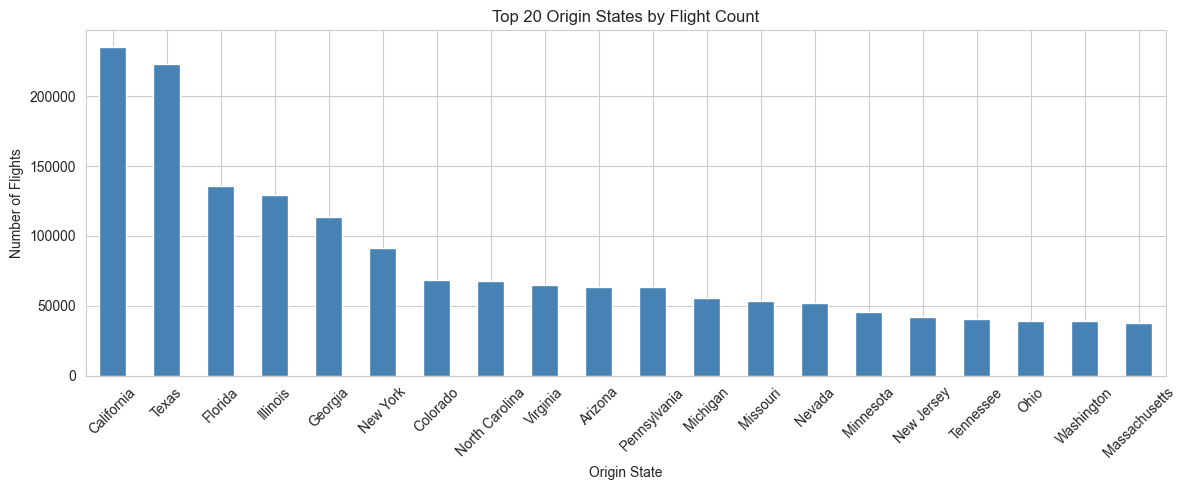

In [18]:
top_states = df['OriginStateName'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 5))
top_states.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Origin State')
ax.set_ylabel('Number of Flights')
ax.set_title('Top 20 Origin States by Flight Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Univariate Discussion

> Summarize the distributions explored above. Note any unusual patterns, skewness, or transformations needed.

> *(fill in after running all univariate cells)*

## Bivariate Exploration

Next we investigate relationships between pairs of variables, focusing on how delay causes relate to airlines, regions, and time.

### Q6: Which delay cause contributes the most minutes on average?

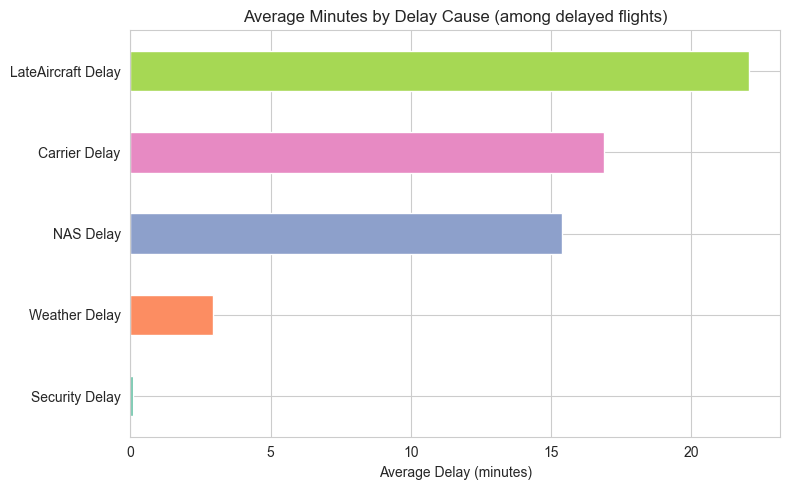

In [19]:
avg_delays = delayed[delay_causes].mean().sort_values(ascending=True)
avg_delays.index = [c.replace('Delay', ' Delay') for c in avg_delays.index]

fig, ax = plt.subplots(figsize=(8, 5))
avg_delays.plot(kind='barh', ax=ax, color=sb.color_palette('Set2', 5))
ax.set_xlabel('Average Delay (minutes)')
ax.set_title('Average Minutes by Delay Cause (among delayed flights)')
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Q7: How do delay rates vary across airlines?

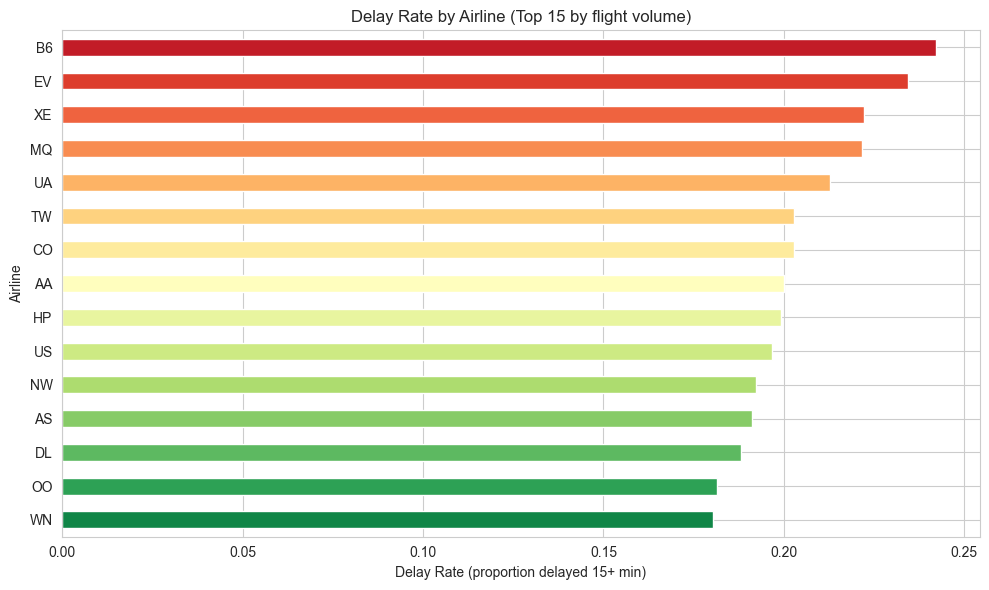

In [20]:
top_15 = df['Reporting_Airline'].value_counts().head(15).index
airline_delay_rate = (df[df['Reporting_Airline'].isin(top_15)]
                      .groupby('Reporting_Airline')['ArrDel15']
                      .mean()
                      .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
colors_grad = sb.color_palette('RdYlGn_r', len(airline_delay_rate))
airline_delay_rate.plot(kind='barh', ax=ax, color=colors_grad)
ax.set_xlabel('Delay Rate (proportion delayed 15+ min)')
ax.set_ylabel('Airline')
ax.set_title('Delay Rate by Airline (Top 15 by flight volume)')
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Q8: How do average delay causes compare across airlines?

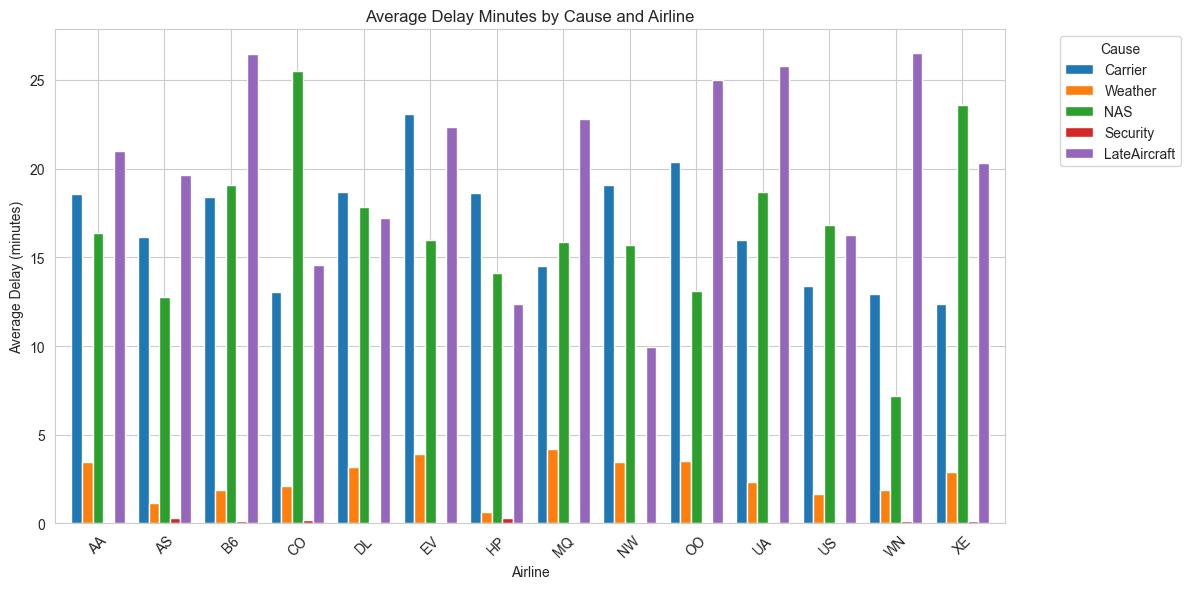

In [21]:
top_15 = df['Reporting_Airline'].value_counts().head(15).index
airline_causes = (delayed[delayed['Reporting_Airline'].isin(top_15)]
                  .groupby('Reporting_Airline')[delay_causes]
                  .mean())
airline_causes.columns = [c.replace('Delay', '') for c in airline_causes.columns]

fig, ax = plt.subplots(figsize=(12, 6))
airline_causes.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Average Delay (minutes)')
ax.set_xlabel('Airline')
ax.set_title('Average Delay Minutes by Cause and Airline')
ax.legend(title='Cause', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Q9: How do delay rates vary by origin state?

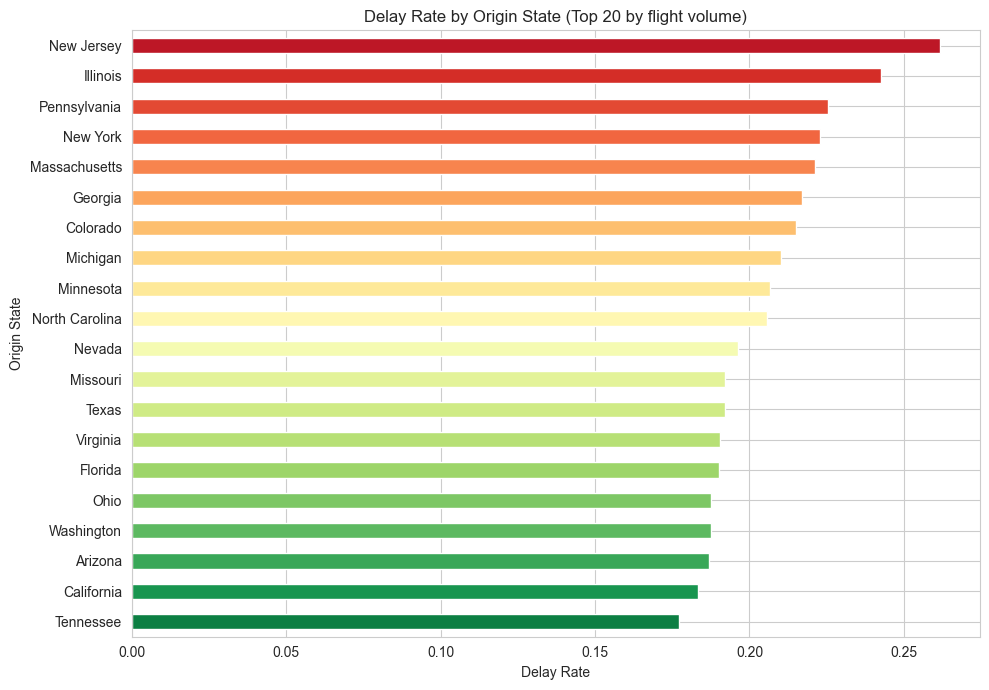

In [22]:
top_20_states = df['OriginStateName'].value_counts().head(20).index
state_delay_rate = (df[df['OriginStateName'].isin(top_20_states)]
                    .groupby('OriginStateName')['ArrDel15']
                    .mean()
                    .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
colors_grad = sb.color_palette('RdYlGn_r', len(state_delay_rate))
state_delay_rate.plot(kind='barh', ax=ax, color=colors_grad)
ax.set_xlabel('Delay Rate')
ax.set_ylabel('Origin State')
ax.set_title('Delay Rate by Origin State (Top 20 by flight volume)')
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Q10: How do delays vary by month?

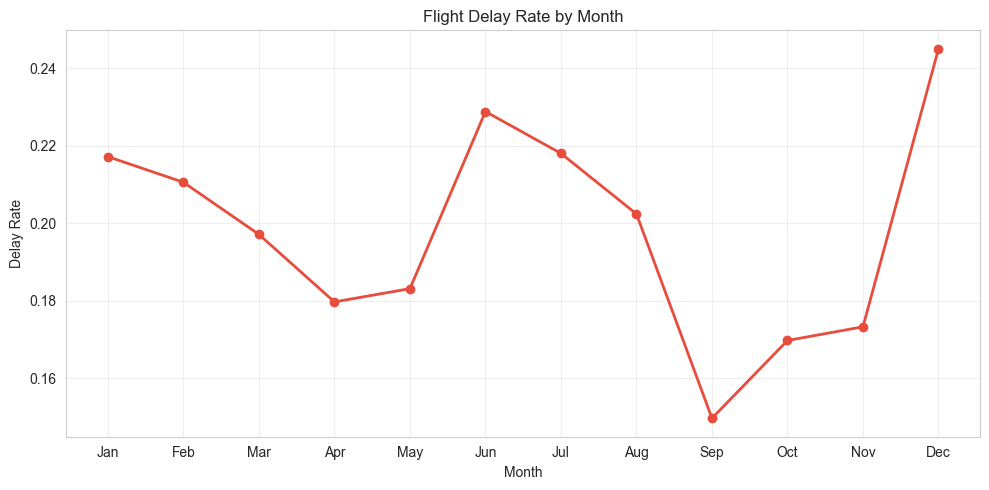

In [23]:
monthly_delay = df.groupby('Month')['ArrDel15'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))
monthly_delay.plot(kind='line', marker='o', ax=ax, color='#e74c3c', linewidth=2)
ax.set_xlabel('Month')
ax.set_ylabel('Delay Rate')
ax.set_title('Flight Delay Rate by Month')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.grid(True, alpha=0.3)
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Bivariate Discussion

> How did the delay causes vary with airlines and regions?

> Did you observe any interesting relationships between the features?

> *(fill in after running all bivariate cells)*

## Multivariate Exploration

Finally, we combine three or more variables to gain deeper insights into delay cause patterns across airlines, regions, and time.

### Q11: What are the delay cause proportions by airline?

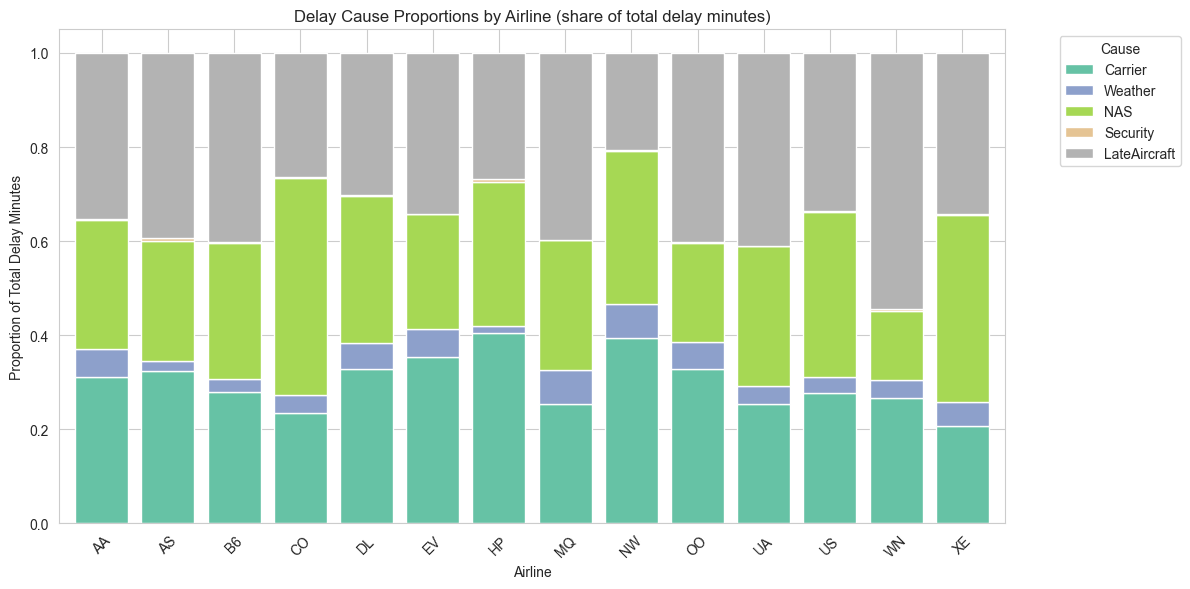

In [24]:
top_15 = df['Reporting_Airline'].value_counts().head(15).index
airline_cause_totals = (delayed[delayed['Reporting_Airline'].isin(top_15)]
                        .groupby('Reporting_Airline')[delay_causes]
                        .sum())
airline_cause_pct = airline_cause_totals.div(airline_cause_totals.sum(axis=1), axis=0)
airline_cause_pct.columns = [c.replace('Delay', '') for c in airline_cause_pct.columns]

fig, ax = plt.subplots(figsize=(12, 6))
airline_cause_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', width=0.8)
ax.set_ylabel('Proportion of Total Delay Minutes')
ax.set_xlabel('Airline')
ax.set_title('Delay Cause Proportions by Airline (share of total delay minutes)')
ax.legend(title='Cause', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Q12: Heatmap of average delay cause minutes by airline

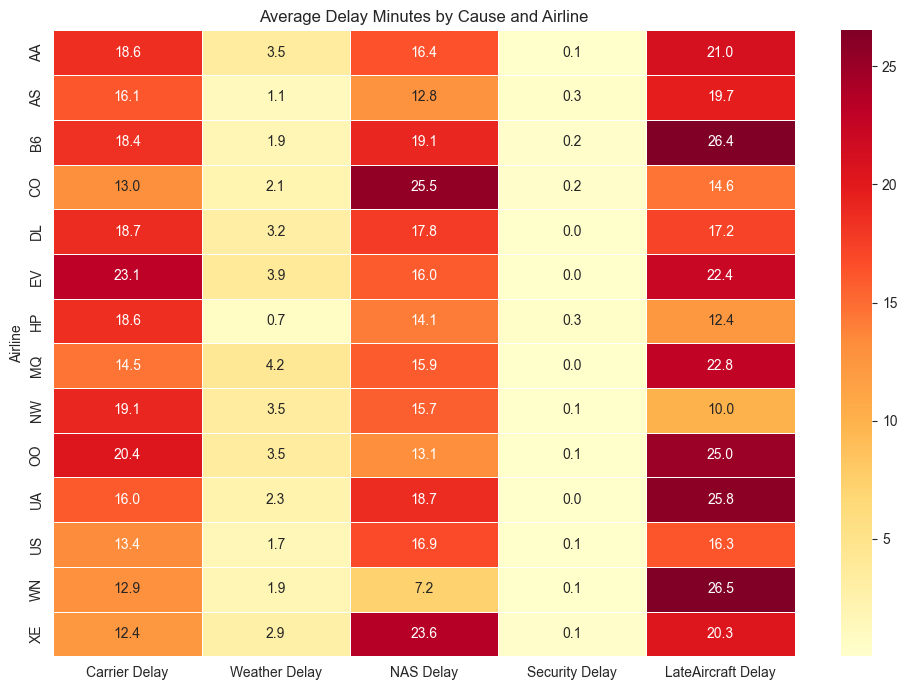

In [25]:
top_15 = df['Reporting_Airline'].value_counts().head(15).index
airline_cause_avg = (delayed[delayed['Reporting_Airline'].isin(top_15)]
                     .groupby('Reporting_Airline')[delay_causes]
                     .mean())
airline_cause_avg.columns = [c.replace('Delay', ' Delay') for c in airline_cause_avg.columns]

fig, ax = plt.subplots(figsize=(10, 7))
sb.heatmap(airline_cause_avg, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Average Delay Minutes by Cause and Airline')
ax.set_ylabel('Airline')
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Q13: How do delay causes vary by month?

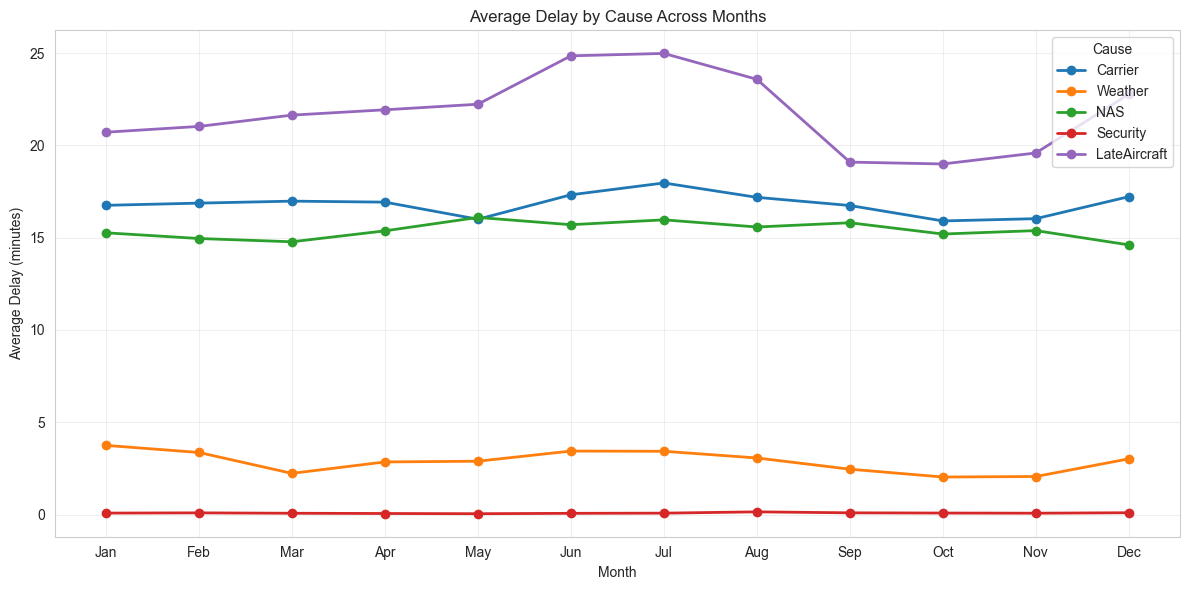

In [26]:
monthly_causes = delayed.groupby('Month')[delay_causes].mean()
monthly_causes.columns = [c.replace('Delay', '') for c in monthly_causes.columns]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 6))
monthly_causes.plot(kind='line', marker='o', ax=ax, linewidth=2)
ax.set_xlabel('Month')
ax.set_ylabel('Average Delay (minutes)')
ax.set_title('Average Delay by Cause Across Months')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend(title='Cause')
ax.grid(True, alpha=0.3)
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Q14: Heatmap of delay causes by origin state

KeyError: 'Late Aircraft Delay'

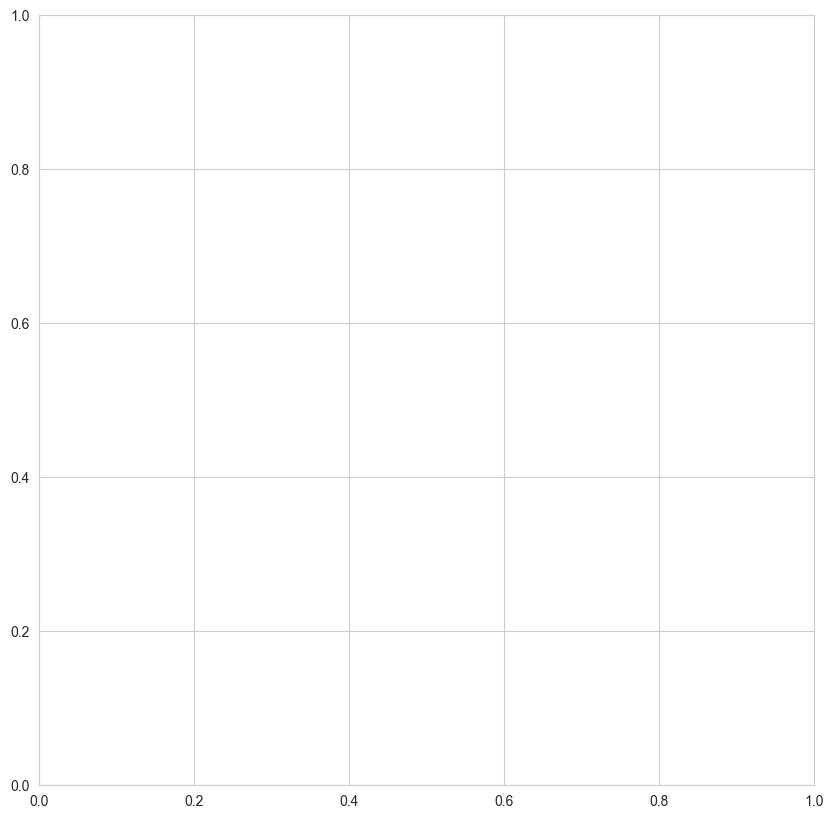

In [27]:
top_20_states = df['OriginStateName'].value_counts().head(20).index
state_cause_avg = (delayed[delayed['OriginStateName'].isin(top_20_states)]
                   .groupby('OriginStateName')[delay_causes]
                   .mean())
state_cause_avg.columns = [c.replace('Delay', ' Delay') for c in state_cause_avg.columns]

fig, ax = plt.subplots(figsize=(10, 10))
sb.heatmap(state_cause_avg.sort_values('Late Aircraft Delay', ascending=False),
           annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Average Delay Minutes by Cause and Origin State')
ax.set_ylabel('State')
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Q15: How have delay cause proportions changed over time?

In [ ]:
yearly_causes = delayed.groupby('Year')[delay_causes].mean()
yearly_causes.columns = [c.replace('Delay', '') for c in yearly_causes.columns]

fig, ax = plt.subplots(figsize=(14, 6))
yearly_causes.plot(kind='area', stacked=True, ax=ax, alpha=0.7, colormap='Set2')
ax.set_xlabel('Year')
ax.set_ylabel('Average Delay (minutes)')
ax.set_title('Delay Cause Trends Over Time (stacked area)')
ax.legend(title='Cause', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout();

> **Observation:** *(fill in after running)*

### Multivariate Discussion

> Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> Were there any interesting or surprising interactions between features?

> *(fill in after running all multivariate cells)*

## Conclusions

> Summarize the main findings from this exploration:
>
> 1. Which delay cause contributes the most to flight delays overall?
> 2. How do delay cause profiles differ across airlines?
> 3. Are there notable regional differences in delay causes?
> 4. What seasonal or temporal patterns exist in delay causes?
>
> *(fill in after completing the full analysis)*